In [295]:
import os
import re
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ----------------- Matplotlib formatting -----------------
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16


RESULTS_DIR = "/scratch/elena/WCTE_recovery/results"

def parse_filename(fname):
    """
    Extract run number, pulse width, chunk id from filename
    Example: Final_run2306_770ps_chunk0.npz
    """
    m = re.match(r"Final_run(\d+)_(\d+)ps_chunk(\d+)\.npz", fname)
    if not m:
        raise ValueError(f"Bad filename: {fname}")
    run, pulse, chunk = int(m.group(1)), int(m.group(2)), int(m.group(3))
    return run, pulse, chunk

# ----------------- collect all files -----------------
all_npz = sorted(f for f in os.listdir(RESULTS_DIR) if f.endswith(".npz"))

grouped_results = defaultdict(list)

for fname in all_npz:
    run, pulse, chunk = parse_filename(fname)
    data = np.load(os.path.join(RESULTS_DIR, fname))
    grouped_results[(run, pulse)].append(data["results"])

merged_results = {}
for key, chunks in grouped_results.items():
    merged_results[key] = np.concatenate(chunks)
    print(f"Run {key[0]}, pulse {key[1]} ps → {len(merged_results[key])} rows")

Run 2055, pulse 810 ps → 1567 rows
Run 2306, pulse 770 ps → 1567 rows
Run 2306, pulse 780 ps → 1567 rows
Run 2306, pulse 790 ps → 1567 rows
Run 2307, pulse 810 ps → 1567 rows


In [296]:
arr = merged_results[(2306, 770)]  #run_number, pulse_width
print(arr.dtype.names)

for row in arr[:20]:  # first 5 rows
    print({name: row[name] for name in arr.dtype.names})

('card_id', 'slot_id', 'channel_id', 'pos_id', 'pedestal_mean', 'pedestal_sigma', 'N_pedestal', 'spe_mean', 'spe_sigma', 'N_spe', 'gain', 'gain_error', 'pulse_ratio', 'mu_pe', 'chi2ndof_spe', 'fit_failed')
{'card_id': 100, 'slot_id': 24, 'channel_id': 0, 'pos_id': 17, 'pedestal_mean': 0.8999999761581421, 'pedestal_sigma': 1.3342775106430054, 'N_pedestal': 8316, 'spe_mean': 152.6999969482422, 'spe_sigma': 27.261343002319336, 'N_spe': 117, 'gain': 151.8000030517578, 'gain_error': inf, 'pulse_ratio': 0.01811764705882353, 'mu_pe': 0.018283781326909956, 'chi2ndof_spe': 0.7526492366447498, 'fit_failed': True}
{'card_id': 100, 'slot_id': 24, 'channel_id': 10, 'pos_id': 10, 'pedestal_mean': 0.6000000238418579, 'pedestal_sigma': 1.1866569519042969, 'N_pedestal': 7960, 'spe_mean': 154.0500030517578, 'spe_sigma': 29.574792861938477, 'N_spe': 292, 'gain': 153.4499969482422, 'gain_error': inf, 'pulse_ratio': 0.055411764705882355, 'mu_pe': 0.057006176293723856, 'chi2ndof_spe': 1.8102398145030583, 'f

In [297]:
arr = merged_results[(2307, 810)]  #run_number, pulse_width
for row in arr[:5]:  # first 5 rows
    print({name: row[name] for name in arr.dtype.names})

{'card_id': 100, 'slot_id': 24, 'channel_id': 0, 'pos_id': 17, 'pedestal_mean': 0.8000001907348633, 'pedestal_sigma': 1.4193189144134521, 'N_pedestal': 5546, 'spe_mean': 148.10000610351562, 'spe_sigma': 26.64919662475586, 'N_spe': 275, 'gain': 147.3000030517578, 'gain_error': inf, 'pulse_ratio': 0.0655, 'mu_pe': 0.06774365208651953, 'chi2ndof_spe': 0.6029401396776153, 'fit_failed': True}
{'card_id': 100, 'slot_id': 24, 'channel_id': 10, 'pos_id': 10, 'pedestal_mean': 0.7999999523162842, 'pedestal_sigma': 1.3588547706604004, 'N_pedestal': 4762, 'spe_mean': 132.1999969482422, 'spe_sigma': 24.28989601135254, 'N_spe': 579, 'gain': 131.39999389648438, 'gain_error': inf, 'pulse_ratio': 0.186, 'mu_pe': 0.20579491297959668, 'chi2ndof_spe': 0.9246992348173202, 'fit_failed': True}
{'card_id': 100, 'slot_id': 24, 'channel_id': 11, 'pos_id': 11, 'pedestal_mean': 0.6000001430511475, 'pedestal_sigma': 1.3971903324127197, 'N_pedestal': 4803, 'spe_mean': 129.8000030517578, 'spe_sigma': 24.341842651367

In [298]:
def build_spe_dict(arr):
    """
    Returns a dictionary:
        key = (card_id, slot_id, channel_id)
        value = (spe_mean, spe_sigma)
    Only includes rows where spe_mean is finite and fit did not fail.
    """
    spe_dict = {}
    for r in arr:
        key = (r["card_id"], r["slot_id"], r["channel_id"])
        spe_dict[key] = (r["spe_mean"], r["spe_sigma"])
    return spe_dict


def plot_spe_ratio_runs(run1, pulse1, run2, pulse2):
    """
    Plots the SPE μ ratio between two runs/pulse widths.
    
    Parameters
    ----------
    run1 : int
        First run number.
    pulse1 : int
        Pulse width (ps) for first run.
    run2 : int
        Second run number.
    pulse2 : int
        Pulse width (ps) for second run.
    """
    # ----------------- Build SPE dictionaries -----------------
    arr1 = merged_results[(run1, pulse1)]
    arr2 = merged_results[(run2, pulse2)]

    spe_dict_1 = build_spe_dict(arr1)
    spe_dict_2 = build_spe_dict(arr2)

    print(f"PMTs in {run1} / {pulse1} ps:", len(spe_dict_1))
    print(f"PMTs in {run2} / {pulse2} ps:", len(spe_dict_2))

    common_pmts = spe_dict_1.keys() & spe_dict_2.keys()
    print("Common PMTs:", len(common_pmts))

    # ----------------- Compute ratio -----------------
    ratio = np.array([spe_dict_2[p][0] / spe_dict_1[p][0] for p in common_pmts])
    print("First 10 ratios:", ratio[:20])

    # ----------------- Prepare data -----------------
    common_pmts = sorted(common_pmts, key=lambda x: (x[0], x[1], x[2]))
    ratio = np.array([spe_dict_2[p][0] / spe_dict_1[p][0] for p in common_pmts])
    x = np.arange(len(common_pmts))

    # Build tick positions and labels: only first channel per mPMT
    tick_positions = []
    tick_labels = []
    seen_mpmt = set()
    for idx, p in enumerate(common_pmts):
        card_slot = (p[0], p[1])
        if card_slot not in seen_mpmt:
            tick_positions.append(idx)
            tick_labels.append(f"card{p[0]}_slot{p[1]}")
            seen_mpmt.add(card_slot)

    # ----------------- Plot -----------------
    fig, ax = plt.subplots(figsize=(16,5), dpi=300)

    ax.scatter(x, ratio, color='purple', alpha=0.6, s=15, label=f"SPE μ ratio")
    ax.axhline(1.0, color='red', linestyle='--', lw=2, label='ratio = 1')

    mean_ratio = np.nanmean(ratio)
    std_ratio = np.nanstd(ratio)
    ax.fill_between(x, mean_ratio-std_ratio, mean_ratio+std_ratio, color='purple', alpha=0.2,
                    label=f"1σ band ({std_ratio:.3f})")
    ax.axhline(mean_ratio, color='purple', lw=1.5, label=f"mean = {mean_ratio:.3f}")

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=12)

    ax.set_ylabel("SPE μ ratio")
    ax.set_xlabel("mPMTs (card_slot)")
    ax.set_title(f"SPE μ ratio per PMT: Run {run1} ({pulse1}ps) vs Run {run2} ({pulse2}ps)")
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

PMTs in 2306 / 770 ps: 1567
PMTs in 2307 / 810 ps: 1567
Common PMTs: 1567
First 10 ratios: [1.05310365 0.80311228 1.03192303 1.12106919 1.16244547 1.07684275
 1.14439327 0.87021945 1.07180067 0.97395833 1.01028101 1.06955301
 1.05382441 1.02496336 0.89626235 1.00696368 0.99126939 1.06769693
 0.94071426 1.00191992]


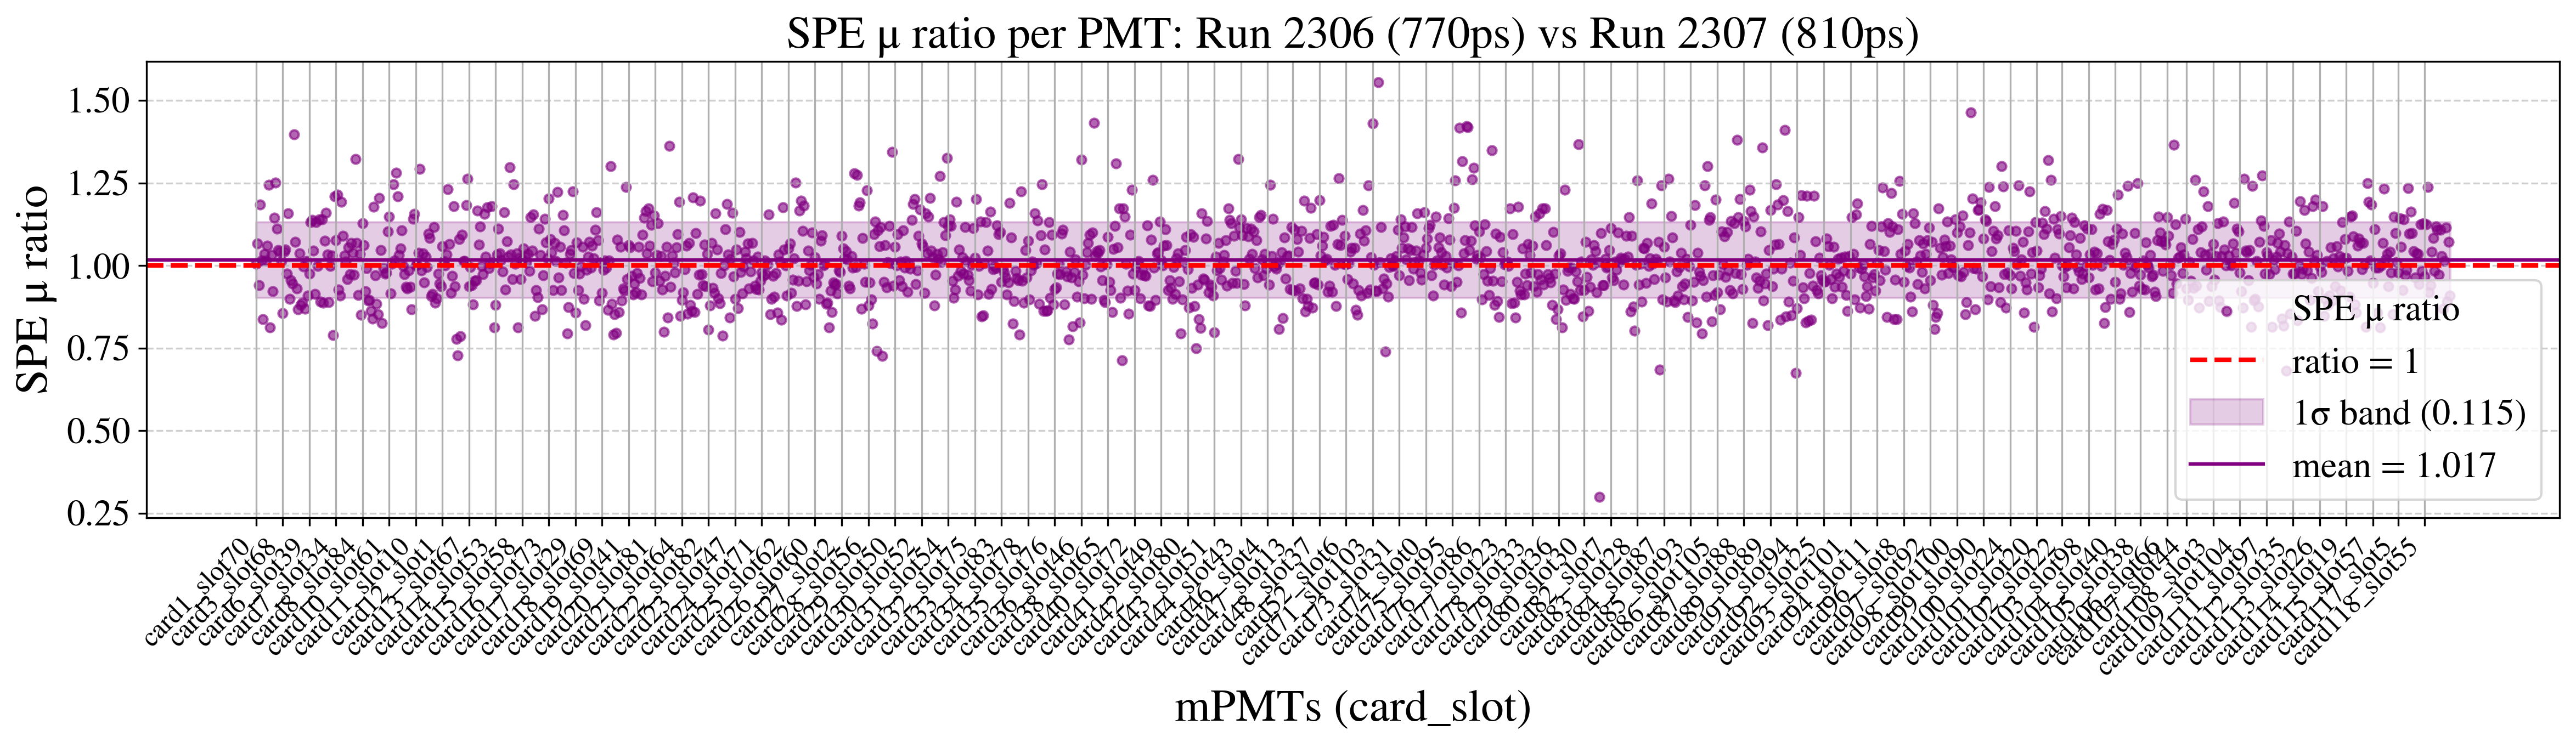

In [299]:
plot_spe_ratio_runs(run1=2306, pulse1=770, run2=2307, pulse2=810)

In [300]:
def build_spe_dict(arr):
    """
    Returns a dictionary:
        key = (card_id, slot_id, channel_id)
        value = (spe_mean, spe_sigma)
    Includes all rows with finite spe_mean and spe_sigma.
    """
    spe_dict = {}
    for r in arr:
        # Skip rows where mean or sigma is not finite
        if not np.isfinite(r['spe_mean']) or not np.isfinite(r['spe_sigma']):
            continue
        key = (r["card_id"], r["slot_id"], r["channel_id"])
        spe_dict[key] = (r["spe_mean"], r["spe_sigma"])
    return spe_dict

In [301]:
def plot_spe_ratio_runs_weighted_filtered(run1, pulse1, run2, pulse2, ignore_pmts=None):
    """
    Plots SPE μ ratio with propagated errors for all valid PMTs, 
    ignores PMTs listados en ignore_pmts.
    Computes weighted mean and 1σ using the ratio errors.
    """
    if ignore_pmts is None:
        ignore_pmts = set()  # PMTs a ignorar
    
    arr1 = merged_results[(run1, pulse1)]
    arr2 = merged_results[(run2, pulse2)]

    spe_dict_1 = build_spe_dict(arr1)
    spe_dict_2 = build_spe_dict(arr2)

    common_pmts = spe_dict_1.keys() & spe_dict_2.keys()
    common_pmts = sorted(common_pmts, key=lambda x: (x[0], x[1], x[2]))

    ratios = []
    err_ratios = []
    filtered_pmts = []

    for p in common_pmts:
        # Saltar PMTs muertos
        if p in ignore_pmts:
            continue

        a, err_a = spe_dict_1[p]
        b, err_b = spe_dict_2[p]

        if a <= 0 or b <= 0 or err_a <= 0 or err_b <= 0:
            continue

        r = b / a
        err_r = r * np.sqrt((err_a / a)**2 + (err_b / b)**2)

        ratios.append(r)
        err_ratios.append(err_r)
        filtered_pmts.append(p)

    ratios = np.array(ratios)
    err_ratios = np.array(err_ratios)
    x = np.arange(len(filtered_pmts))

    # ----------------- Top 10 PMTs -----------------
    diff_from_1 = np.abs(ratios - 1)
    idx_top10_diff = np.argsort(diff_from_1)[-10:][::-1]
    print("Top 10 PMTs con ratio más alejado de 1:")
    for i in idx_top10_diff:
        print(f"PMT {filtered_pmts[i]} → ratio = {ratios[i]:.3f}, error = {err_ratios[i]:.3f}")

    idx_top10_err = np.argsort(err_ratios)[-10:][::-1]
    print("\nTop 10 PMTs con error de ratio más alto:")
    for i in idx_top10_err:
        print(f"PMT {filtered_pmts[i]} → ratio = {ratios[i]:.3f}, error = {err_ratios[i]:.3f}")

    # ----------------- Weighted mean -----------------
    weights = 1 / err_ratios**2
    mean_ratio = np.sum(ratios * weights) / np.sum(weights)
    sigma_ratio = np.sqrt(1 / np.sum(weights))

    # Tick labels
    tick_positions = []
    tick_labels = []
    seen_mpmt = set()
    for idx, p in enumerate(filtered_pmts):
        card_slot = (p[0], p[1])
        if card_slot not in seen_mpmt:
            tick_positions.append(idx)
            tick_labels.append(f"card{p[0]}_slot{p[1]}")
            seen_mpmt.add(card_slot)

    # ----------------- Plot -----------------
    fig, ax = plt.subplots(figsize=(16,5), dpi=300)
    ax.errorbar(x, ratios, yerr=err_ratios, fmt='o', color='purple', alpha=0.5, markersize=6,
                ecolor='gray', elinewidth=1, capsize=2, label="SPE μ ratio ± error")
    ax.axhline(1.0, color='red', linestyle='--', lw=2, label='ratio = 1')
    ax.axhline(mean_ratio, color='purple', lw=1.5, label=f"weighted mean = {mean_ratio:.3f}")
    ax.fill_between(x, mean_ratio - sigma_ratio, mean_ratio + sigma_ratio, color='purple', alpha=0.2,
                    label=f"weighted 1σ = {sigma_ratio:.3f}")
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=12)
    ax.set_ylabel("SPE μ ratio")
    ax.set_xlabel("mPMTs (card_slot)")
    ax.set_title(f"SPE μ ratio per PMT: Run {run1} ({pulse1}ps) vs Run {run2} ({pulse2}ps)")
    #ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc=(1.01,0.1))
    #ax.set_ylim(0, 2)
    plt.tight_layout()
    plt.show()

Top 10 PMTs con ratio más alejado de 1:
PMT (13, 67, 16) → ratio = 1.491, error = 0.435
PMT (40, 72, 6) → ratio = 1.467, error = 0.369
PMT (109, 104, 17) → ratio = 1.465, error = 0.383
PMT (100, 24, 6) → ratio = 1.463, error = 0.412
PMT (25, 62, 11) → ratio = 1.446, error = 0.390
PMT (84, 87, 6) → ratio = 1.443, error = 0.381
PMT (89, 89, 16) → ratio = 1.421, error = 0.386
PMT (114, 19, 5) → ratio = 1.419, error = 0.503
PMT (18, 69, 6) → ratio = 1.417, error = 0.393
PMT (22, 82, 9) → ratio = 1.385, error = 0.368

Top 10 PMTs con error de ratio más alto:
PMT (114, 19, 5) → ratio = 1.419, error = 0.503
PMT (42, 80, 14) → ratio = 1.178, error = 0.457
PMT (13, 67, 16) → ratio = 1.491, error = 0.435
PMT (100, 24, 6) → ratio = 1.463, error = 0.412
PMT (101, 20, 6) → ratio = 1.085, error = 0.409
PMT (71, 103, 5) → ratio = 1.333, error = 0.404
PMT (18, 69, 6) → ratio = 1.417, error = 0.393
PMT (25, 62, 11) → ratio = 1.446, error = 0.390
PMT (89, 89, 16) → ratio = 1.421, error = 0.386
PMT (109,

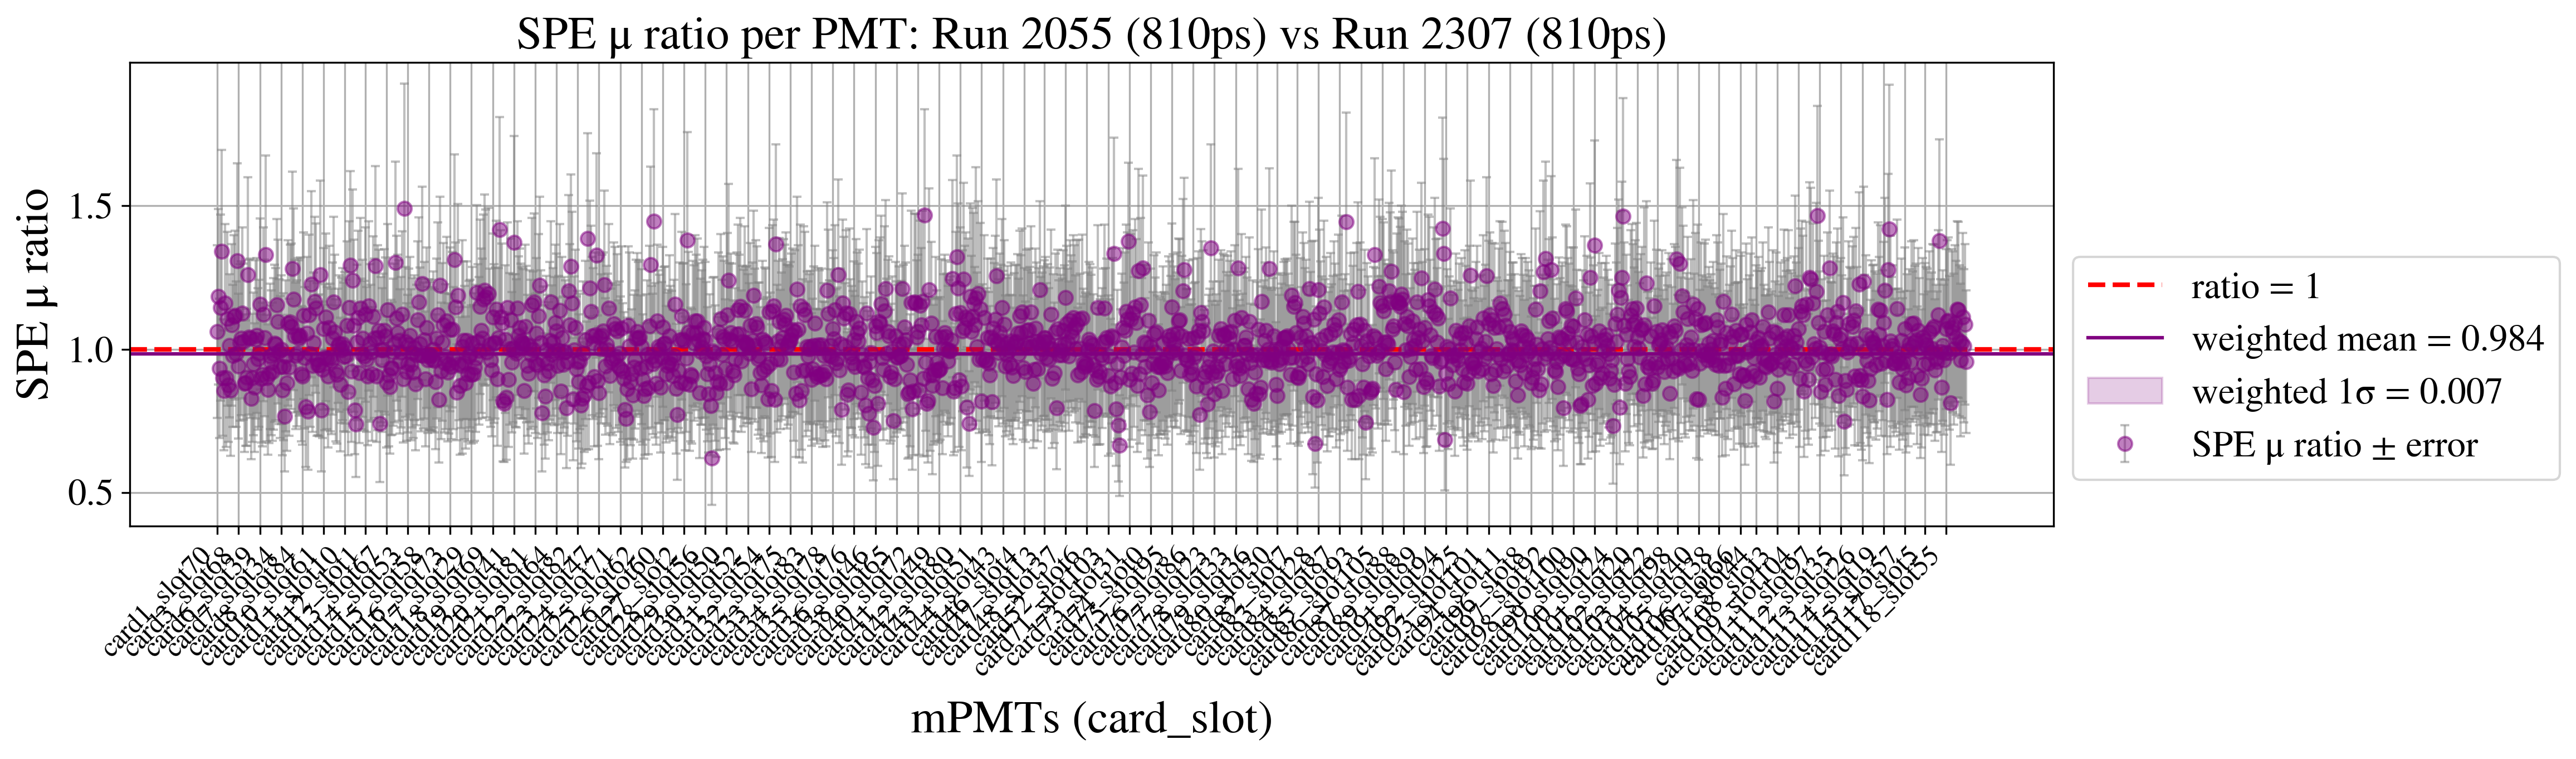

In [302]:
ignore_pmts = {(102, 22, 0), (11, 10, 0), (80,30,11)}
               #(33,83,6), (48,37,6), (79,36,5), (33,83,5), (43,51,12), (38,65,6), (106,66,6), (79,36,8), (33,83,1), (106,66,8), (112,35,4), (79,36,9), (33,83,4), (106,66,5)}
plot_spe_ratio_runs_weighted_filtered(2055, 810, 2307, 810, ignore_pmts=ignore_pmts)

In [303]:
def plot_topN_ratio_pmts(run1, pulse1, run2, pulse2, ignore_pmts=None, topN=10):
    """
    Plots SPE μ ratio only for the top 10 PMTs with ratio furthest from 1,
    ignoring PMTs in ignore_pmts.
    """
    if ignore_pmts is None:
        ignore_pmts = set()
    
    arr1 = merged_results[(run1, pulse1)]
    arr2 = merged_results[(run2, pulse2)]

    spe_dict_1 = build_spe_dict(arr1)
    spe_dict_2 = build_spe_dict(arr2)

    common_pmts = spe_dict_1.keys() & spe_dict_2.keys()
    common_pmts = sorted(common_pmts, key=lambda x: (x[0], x[1], x[2]))

    ratios = []
    err_ratios = []
    filtered_pmts = []

    for p in common_pmts:
        if p in ignore_pmts:
            continue
        a, err_a = spe_dict_1[p]
        b, err_b = spe_dict_2[p]
        if a <= 0 or b <= 0 or err_a <= 0 or err_b <= 0:
            continue
        r = b / a
        err_r = r * np.sqrt((err_a / a)**2 + (err_b / b)**2)
        ratios.append(r)
        err_ratios.append(err_r)
        filtered_pmts.append(p)

    ratios = np.array(ratios)
    err_ratios = np.array(err_ratios)
    filtered_pmts = np.array(filtered_pmts)  # para indexar fácilmente

    # ----------------- Top 10 PMTs con ratio más alejado de 1 -----------------
    diff_from_1 = np.abs(ratios - 1)
    idx_top10 = np.argsort(diff_from_1)[-topN:][::-1]

    # Solo quedarnos con esos PMTs
    ratios_top10 = ratios[idx_top10]
    err_ratios_top10 = err_ratios[idx_top10]
    pmts_top10 = filtered_pmts[idx_top10]
    x = np.arange(len(pmts_top10))

    sort_idx = np.argsort(ratios_top10) 
    print(f"Top {topN} PMTs with ratio furthest from 1 (dead PMTs filtered, increasing order of ratio):")
    for i in sort_idx:
        print(f"PMT {pmts_top10[i]} → ratio = {ratios_top10[i]:.3f}, error = {err_ratios_top10[i]:.3f}")


    # ----------------- Weighted mean de estos 10 PMTs -----------------
    weights = 1 / err_ratios_top10**2
    mean_ratio = np.sum(ratios_top10 * weights) / np.sum(weights)
    sigma_ratio = np.sqrt(1 / np.sum(weights))

    # Tick labels
    tick_labels = [f"card{p[0]}_slot{p[1]}_ch{p[2]}" for p in pmts_top10]

    # ----------------- Plot -----------------
    fig, ax = plt.subplots(figsize=(16,5), dpi=300)
    ax.errorbar(x, ratios_top10, yerr=err_ratios_top10, fmt='o', color='purple', alpha=0.5, markersize=6,
                ecolor='k', elinewidth=1, capsize=2, label="SPE μ ratio ± error")
    ax.axhline(1.0, color='red', linestyle='--', lw=2, label='ratio = 1')
    ax.axhline(mean_ratio, color='purple', lw=1.5, label=f"weighted mean = {mean_ratio:.3f}")
    ax.fill_between(x, mean_ratio - sigma_ratio, mean_ratio + sigma_ratio, color='purple', alpha=0.2,
                    label=f"weighted 1σ = {sigma_ratio:.3f}")
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=12)
    ax.set_ylabel("SPE μ ratio")
    ax.set_xlabel(f"Top {topN} PMTs")
    ax.set_title(f"Top {topN} SPE μ worst ratio: Run {run1} ({pulse1}ps) vs Run {run2} ({pulse2}ps)")
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc=(1.01,0.1))
    #ax.set_ylim(0, 2)
    plt.tight_layout()
    plt.show()

Top 50 PMTs with ratio furthest from 1 (dead PMTs filtered, increasing order of ratio):
PMT [28 56  6] → ratio = 0.620, error = 0.164
PMT [ 71 103  10] → ratio = 0.664, error = 0.175
PMT [82  7 16] → ratio = 0.671, error = 0.155
PMT [89 89 18] → ratio = 0.684, error = 0.177
PMT [35 76 17] → ratio = 0.728, error = 0.186
PMT [96  8 11] → ratio = 1.270, error = 0.319
PMT [ 86 105   8] → ratio = 1.272, error = 0.350
PMT [73 31  8] → ratio = 1.273, error = 0.355
PMT [114  19   4] → ratio = 1.277, error = 0.335
PMT [96  8 18] → ratio = 1.278, error = 0.326
PMT [75 95 11] → ratio = 1.278, error = 0.321
PMT [79 36 12] → ratio = 1.280, error = 0.351
PMT [ 7 34 10] → ratio = 1.281, error = 0.338
PMT [111  97   9] → ratio = 1.283, error = 0.270
PMT [73 31 12] → ratio = 1.283, error = 0.322
PMT [78 33  2] → ratio = 1.283, error = 0.346
PMT [21 64 13] → ratio = 1.289, error = 0.319
PMT [12  1  9] → ratio = 1.291, error = 0.348
PMT [11 10  6] → ratio = 1.292, error = 0.328
PMT [25 62  8] → ratio = 1

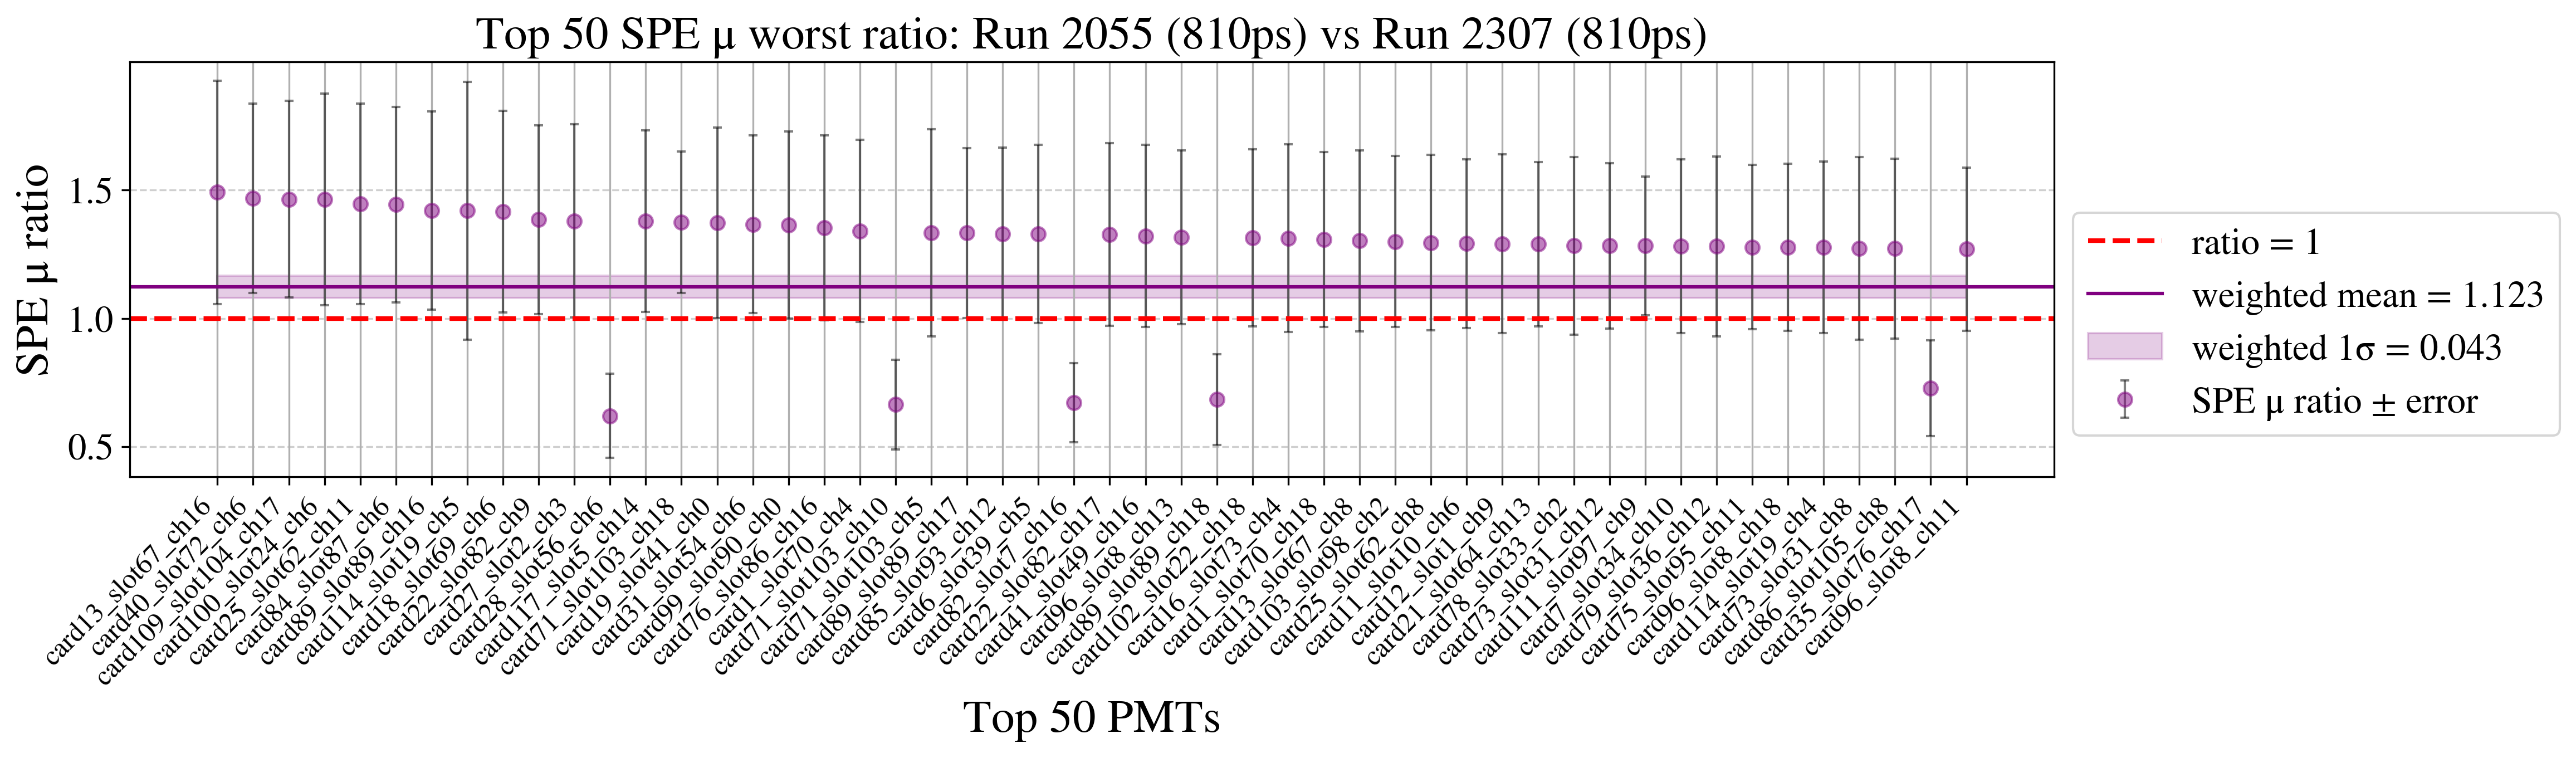

In [304]:
plot_topN_ratio_pmts(2055, 810, 2307, 810, ignore_pmts=ignore_pmts, topN=50)